In [38]:
import uproot
import pandas as pd
import numpy as np
import glob


In [39]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [40]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"

cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_dz',"Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane",'Pip_dr','Dp_CMS_p','Dp_cosHelicityAngleMomentum','Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [41]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [42]:
df_proc13.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,199033.000000,199033.000000,1.990330e+05,199033.000000,199033.000000,199033.000000,199033.000000,199033.000000,199033.000000,199033.000000
mean,0.017748,0.999468,1.923368e-02,3.425882,-0.173415,1.762292,0.104096,0.359788,1.594501,-0.005622
std,0.044587,0.002045,2.150023e-02,0.530875,0.456113,0.153027,0.487644,0.497640,0.858915,0.999987
min,-0.267379,0.896296,9.875111e-07,2.500026,-0.919140,1.500001,-0.999612,-0.903704,0.400001,-1.000000
25%,-0.010884,0.999713,6.773591e-03,3.001645,-0.568484,1.634797,-0.300692,-0.014619,0.872372,-1.000000
50%,0.014638,0.999955,1.276833e-02,3.387907,-0.210131,1.745907,0.128232,0.484188,1.474365,-1.000000
75%,0.042284,0.999996,2.396140e-02,3.810134,0.188000,1.878997,0.523726,0.801709,2.164541,1.000000
max,0.633184,1.000000,7.328432e-01,4.995952,0.999391,2.099998,0.999910,0.978369,5.847296,1.000000


In [43]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [44]:
df_proc13.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000,120534.000000
mean,0.017976,0.999483,0.020497,3.479330,-0.193358,1.864020,0.096004,0.361082,1.620571,-0.007400
std,0.045778,0.002014,0.023022,0.535560,0.459782,0.101379,0.485638,0.498576,0.886848,0.999977
min,-0.261453,0.916571,0.000002,2.500055,-0.919140,1.700001,-0.999567,-0.903704,0.400001,-1.000000
25%,-0.011191,0.999738,0.007010,3.057099,-0.594397,1.766716,-0.305491,-0.016008,0.874688,-1.000000
50%,0.014494,0.999961,0.013520,3.455518,-0.229192,1.867806,0.112554,0.486267,1.498946,-1.000000
75%,0.042360,0.999996,0.025578,3.873816,0.167913,1.964116,0.511183,0.805482,2.205772,1.000000
max,0.633184,1.000000,0.732843,4.995952,0.969258,2.099998,0.999910,0.978369,5.847296,1.000000


In [45]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_dz                                                 False
Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane    False
Pip_dr                                                False
Dp_CMS_p                                              False
Dp_cosHelicityAngleMomentum                           False
Dp_M                                                  False
Dp_CMS_cosTheta                                       False
Pip_cosTheta                                          False
Pip_p                                                 False
Pip_charge                                            False
dtype: bool


In [46]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_false"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    # pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/all/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/*.BCS.root"


    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_dz',"Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane",'Pip_dr','Dp_CMS_p','Dp_cosHelicityAngleMomentum','Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [47]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [48]:
df_mc15rd.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,689311.000000,689311.000000,6.893110e+05,689311.000000,689311.000000,689311.000000,689311.000000,689311.000000,689311.000000,689311.000000
mean,0.017560,0.999504,1.868399e-02,3.380079,-0.152774,1.760338,0.086531,0.330229,1.602185,-0.000776
std,0.044771,0.001814,1.989663e-02,0.521760,0.441063,0.152243,0.489553,0.488810,0.821313,1.000000
min,-0.418412,0.912670,3.855031e-07,2.500021,-0.931115,1.500002,-0.998472,-0.905708,0.400009,-1.000000
25%,-0.011296,0.999712,7.036309e-03,2.959918,-0.524894,1.633904,-0.320979,-0.044414,0.929656,-1.000000
50%,0.014768,0.999955,1.277728e-02,3.335803,-0.184565,1.741691,0.107244,0.431485,1.487849,-1.000000
75%,0.042417,0.999996,2.324195e-02,3.757475,0.194027,1.879445,0.507356,0.762743,2.138898,1.000000
max,3.329230,1.000000,5.430208e-01,5.023246,0.995779,2.099997,0.999975,0.979417,5.860589,1.000000


In [49]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [50]:
df_mc15rd.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,412720.000000,412720.000000,4.127200e+05,412720.000000,412720.000000,412720.000000,412720.000000,412720.000000,412720.000000,412720.000000
mean,0.018046,0.999523,1.997270e-02,3.430209,-0.170359,1.863129,0.081189,0.329539,1.631744,0.001216
std,0.045957,0.001779,2.146585e-02,0.528412,0.443750,0.100835,0.487392,0.489343,0.844783,1.000000
min,-0.418412,0.912670,3.855031e-07,2.500021,-0.931115,1.700000,-0.996802,-0.905708,0.400011,-1.000000
25%,-0.011282,0.999738,7.307609e-03,3.005941,-0.545553,1.764969,-0.321882,-0.048644,0.941326,-1.000000
50%,0.014904,0.999961,1.348944e-02,3.400175,-0.199962,1.868081,0.096341,0.430828,1.518920,1.000000
75%,0.042861,0.999997,2.482596e-02,3.820393,0.175564,1.964779,0.496571,0.764324,2.180797,1.000000
max,3.329230,1.000000,5.200313e-01,5.013437,0.983994,2.099997,0.999975,0.979004,5.860589,1.000000


In [51]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_dz                                                 False
Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane    False
Pip_dr                                                False
Dp_CMS_p                                              False
Dp_cosHelicityAngleMomentum                           False
Dp_M                                                  False
Dp_CMS_cosTheta                                       False
Pip_cosTheta                                          False
Pip_p                                                 False
Pip_charge                                            False
dtype: bool


In [52]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [53]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


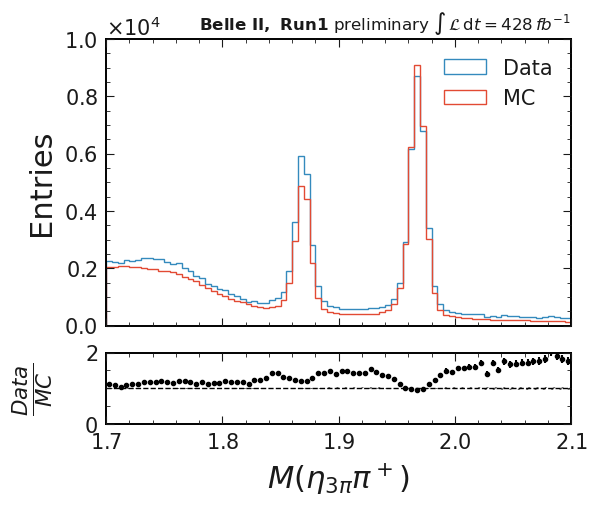

In [54]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

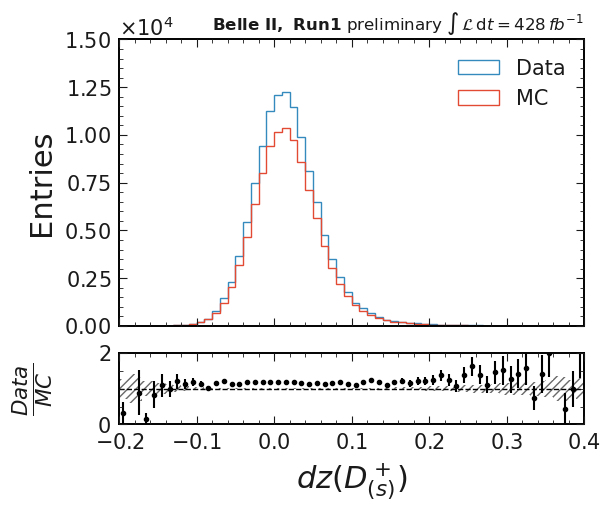

In [55]:
name = "Dp_dz"
category = "category"
xlabel = r"$dz(D^+_{(s)})$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (-0.2,0.4)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

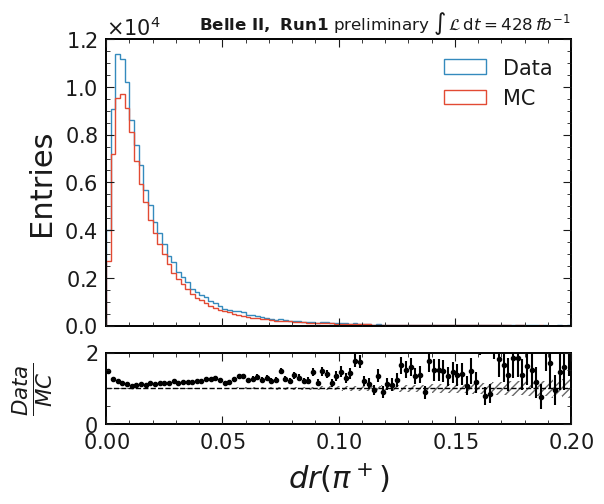

In [56]:
name = "Pip_dr"
category = "category"
xlabel = r'$dr(\pi^+)$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0,0.2)

h1 = make_hist(x1, bins=100, range=x_range, weights=1)
h2 = make_hist(x2, bins=100, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

/tmp/ipykernel_15532/3649880249.py:15: RangeWarning: Only 89.44% of data contained in the binning range [0.999, 1.0].
  h1 = make_hist(x1, bins=100, range=x_range, weights=1)
/tmp/ipykernel_15532/3649880249.py:16: RangeWarning: Only 89.76% of data contained in the binning range [0.999, 1.0].
  h2 = make_hist(x2, bins=100, range=x_range, weights=1/4)


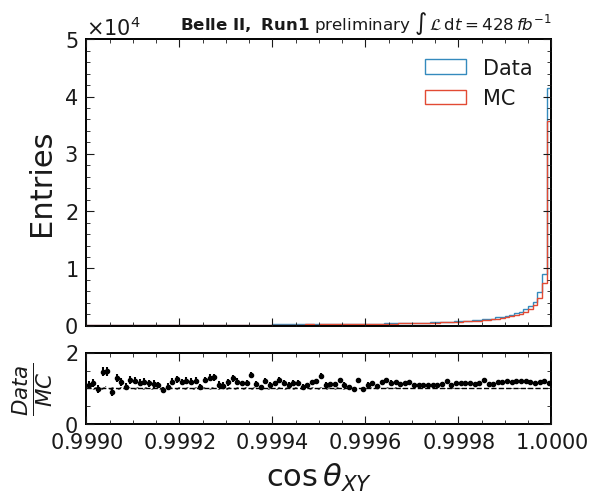

In [57]:
name = "Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane"
category = "category"
xlabel = r'$\cos \theta_{XY}$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0.999,1)

h1 = make_hist(x1, bins=100, range=x_range, weights=1)
h2 = make_hist(x2, bins=100, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=100, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

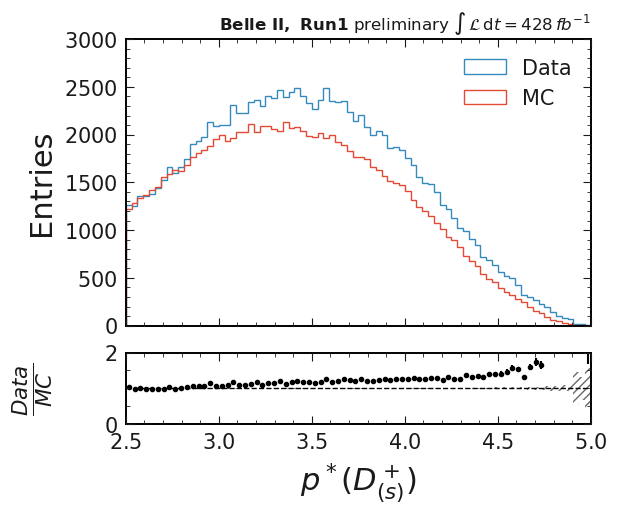

In [58]:
name = "Dp_CMS_p"
category = "category"
xlabel = r'$p^*(D^+_{(s)})$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (2.5,5.0)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

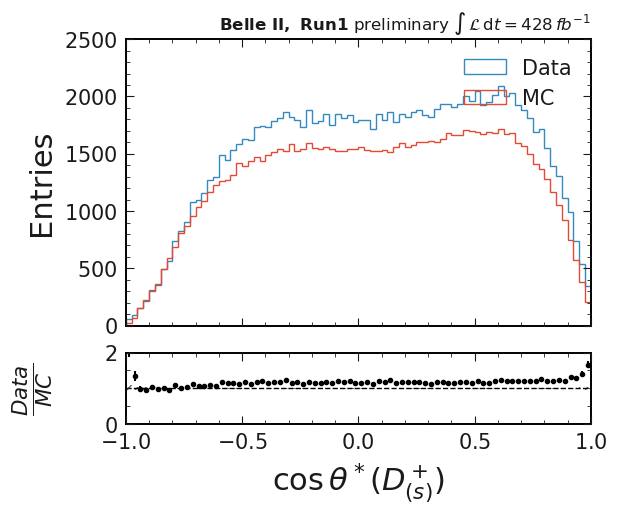

In [59]:
name = "Dp_CMS_cosTheta"
category = "category"
xlabel = r'$\cos\theta^*(D^+_{(s)})$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (-1,1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4))
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")